**Секція 1. Логістична регресія з нуля.**

Будемо крок за кроком будувати модель лог регресії з нуля для передбачення, чи буде врожай більше за 80 яблук (задача подібна до лекційної, але на класифікацію).

Давайте нагадаємо основні формули для логістичної регресії.

### Функція гіпотези - обчислення передбачення у логістичній регресії:

$$
\hat{y} = \sigma(x W^T + b) = \frac{1}{1 + e^{-(x W^T + b)}}
$$

Де:
- $ \hat{y} $ — це ймовірність "позитивного" класу.
- $ x $ — це вектор (або матриця для набору прикладів) вхідних даних.
- $ W $ — це вектор (або матриця) вагових коефіцієнтів моделі.
- $ b $ — це зміщення (bias).
- $ \sigma(z) $ — це сигмоїдна функція активації.

### Як обчислюється сигмоїдна функція:

Сигмоїдна функція $ \sigma(z) $ має вигляд:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Ця функція перетворює будь-яке дійсне значення $ z $ в інтервал від 0 до 1, що дозволяє інтерпретувати вихід як ймовірність для логістичної регресії.

### Формула функції втрат для логістичної регресії (бінарна крос-ентропія):

Функція втрат крос-ентропії оцінює, наскільки добре модель передбачає класи, порівнюючи передбачені ймовірності $ \hat{y} $ із справжніми мітками $ y $. Формула наступна:

$$
L(y, \hat{y}) = - \left[ y \cdot \log(\hat{y}) + (1 - y) \cdot \log(1 - \hat{y}) \right]
$$

Де:
- $ y $ — це справжнє значення (мітка класу, 0 або 1).
- $ \hat{y} $ — це передбачене значення (ймовірність).



1.
Тут вже наведений код для ініціювання набору даних в форматі numpy. Перетворіть `inputs`, `targets` на `torch` тензори. Виведіть результат на екран.

In [1]:
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from torch.optim import SGD

In [2]:
# Вхідні дані (temp, rainfall, humidity)
inputs = np.array([[73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70]], dtype='float32')

# Таргети (apples > 80)
targets = np.array([[0],
                    [1],
                    [1],
                    [0],
                    [1]], dtype='float32')

In [3]:
inputs_tensor = torch.from_numpy(inputs)
targets_tensor = torch.from_numpy(targets)

print("Inputs tensor:\n", inputs_tensor)
print("\nTargets tensor:\n", targets_tensor)

Inputs tensor:
 tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [ 87., 134.,  58.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.]])

Targets tensor:
 tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.]])


2. Ініціюйте ваги `w`, `b` для моделі логістичної регресії потрібної форми зважаючи на розмірності даних випадковими значеннями з нормального розподілу. Лишаю тут код для фіксації `random_seed`.

In [4]:
torch.random.manual_seed(1)

In [5]:
w = torch.randn(3, 1, dtype=torch.float32, requires_grad=True)
b = torch.randn(1, dtype=torch.float32, requires_grad=True)

print("Weights (w):\n", w)
print("\nBias (b):\n", b)

Weights (w):
 tensor([[0.6614],
        [0.2669],
        [0.0617]], requires_grad=True)

Bias (b):
 tensor([0.6213], requires_grad=True)


3. Напишіть функцію `model`, яка буде обчислювати функцію гіпотези в логістичній регресії і дозволяти робити передбачення на основі введеного рядка даних і коефіцієнтів в змінних `w`, `b`.

  **Важливий момент**, що функція `model` робить обчислення на `torch.tensors`, тож для математичних обчислень використовуємо фукнціонал `torch`, наприклад:
  - обчсилення $e^x$: `torch.exp(x)`
  - обчсилення $log(x)$: `torch.log(x)`
  - обчислення середнього значення вектору `x`: `torch.mean(x)`

  Використайте функцію `model` для обчислення передбачень з поточними значеннями `w`, `b`.Виведіть результат обчислень на екран.

  Проаналізуйте передбачення. Чи не викликають вони у вас підозр? І якщо викликають, то чим це може бути зумовлено?

In [6]:
def model(x, w, b):
    z = torch.matmul(x, w) + b
    return 1 / (1 + torch.exp(-z))

preds = model(inputs_tensor, w, b)
print(preds)

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]], grad_fn=<MulBackward0>)


### Summary

All predictions turned out to be **1.0**, which looks unrealistic for random weights.
This happens because the weights and bias were initialized with large values, and the sigmoid function became **saturated**, always giving results close to 1.
In simple terms, the model is “too confident” without actually knowing anything yet.
After training, when the weights adjust to the data, the predictions should stop being all ones and start showing more variation that actually reflects the dataset.


4. Напишіть функцію `binary_cross_entropy`, яка приймає на вхід передбачення моделі `predicted_probs` та справжні мітки в даних `true_labels` і обчислює значення втрат (loss)  за формулою бінарної крос-ентропії для кожного екземпляра та вертає середні втрати по всьому набору даних.
  Використайте функцію `binary_cross_entropy` для обчислення втрат для поточних передбачень моделі.

In [7]:
def binary_cross_entropy(predicted_probs, true_labels, eps=1e-7):
    predicted_probs = torch.clamp(predicted_probs, eps, 1 - eps)
    loss = - (true_labels * torch.log(predicted_probs) + (1 - true_labels) * torch.log(1 - predicted_probs))
    return torch.mean(loss)

loss = binary_cross_entropy(preds, targets_tensor)
print(loss)

tensor(6.3770, grad_fn=<MeanBackward0>)


5. Зробіть зворотнє поширення помилки і виведіть градієнти за параметрами `w`, `b`. Проаналізуйте їх значення. Як гадаєте, чому вони саме такі?

In [8]:
if w.grad is not None:
    w.grad.zero_()
if b.grad is not None:
    b.grad.zero_()

preds = model(inputs_tensor, w, b)
loss = binary_cross_entropy(preds, targets_tensor)
loss.backward()

print("w.grad:\n", w.grad)
print("\nb.grad:\n", b.grad)

w.grad:
 tensor([[0.],
        [0.],
        [0.]])

b.grad:
 tensor([0.])


### Summary

After backpropagation, all gradients for `w` and `b` turned out to be **0**.
This means the model cannot update its weights — the learning process is effectively “stuck.”
As a result, the model has no direction to adjust its parameters.


**Що сталось?**

В цій задачі, коли ми ініціювали значення випадковими значеннями з нормального розподілу, насправді ці значення не були дуже гарними стартовими значеннями і привели до того, що градієнти стали дуже малими або навіть рівними нулю (це призводить до того, що градієнти "зникають"), і відповідно при оновленні ваг у нас не буде нічого змінюватись. Це називається `gradient vanishing`. Це відбувається через **насичення сигмоїдної функції активації.**

У нашій задачі ми використовуємо сигмоїдну функцію активації, яка має такий вигляд:

   $$
   \sigma(z) = \frac{1}{1 + e^{-z}}
   $$


Коли значення $z$ дуже велике або дуже мале, сигмоїдна функція починає "насичуватись". Це означає, що для великих позитивних $z$ сигмоїда наближається до 1, а для великих негативних — до 0. В цих діапазонах градієнти починають стрімко зменшуватись і наближаються до нуля (бо градієнт - це похідна, похідна на проміжку функції, де вона паралельна осі ОХ, дорівнює 0), що робить оновлення ваг неможливим.

![](https://editor.analyticsvidhya.com/uploads/27889vaegp.png)

У логістичній регресії $ z = x \cdot w + b $. Якщо ваги $w, b$ - великі, значення $z$ також буде великим, і сигмоїда перейде в насичену область, де градієнти дуже малі.

Саме це сталося в нашій задачі, де великі випадкові значення ваг викликали насичення сигмоїдної функції. Це в свою чергу призводить до того, що під час зворотного поширення помилки (backpropagation) модель оновлює ваги дуже повільно або зовсім не оновлює. Це називається проблемою **зникнення градієнтів** (gradient vanishing problem).

**Що ж робити?**
Ініціювати ваги маленькими значеннями навколо нуля. Наприклад ми можемо просто в існуючій ініціалізації ваги розділити на 1000. Можна також використати інший спосіб ініціалізації вагів - інформація про це [тут](https://www.geeksforgeeks.org/initialize-weights-in-pytorch/).

Як це робити - показую нижче. **Виконайте код та знову обчисліть передбачення, лосс і виведіть градієнти.**

А я пишу пояснення, чому просто не зробити

```
w = torch.randn(1, 3, requires_grad=True)/1000
b = torch.randn(1, requires_grad=True)/1000
```

Нам потрібно, аби тензори вагів були листовими (leaf tensors).

1. **Що таке листовий тензор**
Листовий тензор — це тензор, який був створений користувачем безпосередньо і з якого починається обчислювальний граф. Якщо такий тензор має `requires_grad=True`, PyTorch буде відслідковувати всі операції, виконані над ним, щоб правильно обчислювати градієнти під час навчання.

2. **Чому ми використовуємо `w.data` замість звичайних операцій**
Якщо ми просто виконали б операції, такі як `(w - 0.5) / 100`, ми б отримали **новий тензор**, який вже не був би листовим тензором, оскільки ці операції створюють **новий** тензор, а не модифікують існуючий.

  Проте, щоб залишити наші тензори ваги `w` та зміщення `b` листовими і продовжити можливість відстеження градієнтів під час тренування, ми використовуємо атрибут `.data`. Цей атрибут дозволяє **виконувати операції in-place (прямо на існуючому тензорі)** без зміни самого об'єкта тензора. Отже, тензор залишається листовим, і PyTorch може коректно обчислювати його градієнти.

3. **Чому важливо залишити тензор листовим**
Якщо тензор більше не є листовим (наприклад, через проведення операцій, що створюють нові тензори), ви не зможете отримати градієнти за допомогою `w.grad` чи `b.grad` після виклику `loss.backward()`. Це може призвести до втрати можливості оновлення параметрів під час тренування моделі. В нашому випадку ми хочемо, щоб тензори `w` та `b` накопичували градієнти, тому вони повинні залишатись листовими.

**Висновок:**
Ми використовуємо `.data`, щоб виконати операції зміни значень на ваги і зміщення **in-place**, залишаючи їх листовими тензорами, які можуть накопичувати градієнти під час навчання. Це дозволяє коректно працювати механізму зворотного поширення помилки (backpropagation) і оновлювати ваги моделі.

5. Виконайте код та знову обчисліть передбачення, лосс і знайдіть градієнти та виведіть всі ці тензори на екран.

In [9]:
torch.random.manual_seed(1)
w = torch.randn(3, 1, requires_grad=True)  # Листовий тензор
b = torch.randn(1, requires_grad=True)     # Листовий тензор

# in-place операції
w.data = w.data / 1000
b.data = b.data / 1000

In [10]:
preds = model(inputs_tensor, w, b)
print("Predictions:\n", preds)

loss = binary_cross_entropy(preds, targets_tensor)
print("\nLoss:\n", loss)

if w.grad is not None:
    w.grad.zero_()
if b.grad is not None:
    b.grad.zero_()

loss.backward()

print("\nw.grad:\n", w.grad)
print("\nb.grad:\n", b.grad)

Predictions:
 tensor([[0.5174],
        [0.5220],
        [0.5244],
        [0.5204],
        [0.5190]], grad_fn=<MulBackward0>)

Loss:
 tensor(0.6829, grad_fn=<MeanBackward0>)

w.grad:
 tensor([[ -5.4417],
        [-18.9853],
        [-10.0682]])

b.grad:
 tensor([-0.0794])


6. Напишіть алгоритм градієнтного спуску, який буде навчати модель з використанням написаних раніше функцій і виконуючи оновлення ваг. Алгоритм має включати наступні кроки:

  1. Генерація прогнозів
  2. Обчислення втрат
  3. Обчислення градієнтів (gradients) loss-фукнції відносно ваг і зсувів
  4. Налаштування ваг шляхом віднімання невеликої величини, пропорційної градієнту (`learning_rate` домножений на градієнт)
  5. Скидання градієнтів на нуль

Виконайте градієнтний спуск протягом 1000 епох, обчисліть фінальні передбачення і проаналізуйте, чи вони точні?

In [11]:
learning_rate = 0.001
epochs = 1000

for epoch in range(epochs):
    preds = model(inputs_tensor, w, b)
    loss = binary_cross_entropy(preds, targets_tensor)
    loss.backward()
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad
    w.grad.zero_()
    b.grad.zero_()
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.4f}")

final_preds = model(inputs_tensor, w, b)
preds_rounded = torch.round(final_preds)
for i, (pred, true) in enumerate(zip(final_preds, targets_tensor)):
    print(f"Predicted={pred.item():.4f}")
print("\nFinal weights:\n", w)
print("\nFinal bias:\n", b)


Epoch 100, Loss: 0.1981
Epoch 200, Loss: 0.1625
Epoch 300, Loss: 0.1382
Epoch 400, Loss: 0.1198
Epoch 500, Loss: 0.1054
Epoch 600, Loss: 0.0937
Epoch 700, Loss: 0.0842
Epoch 800, Loss: 0.0763
Epoch 900, Loss: 0.0697
Epoch 1000, Loss: 0.0640
Predicted=0.1679
Predicted=0.8749
Predicted=0.9977
Predicted=0.0000
Predicted=1.0000

Final weights:
 tensor([[-0.3149],
        [ 0.1057],
        [ 0.3330]], requires_grad=True)

Final bias:
 tensor([-0.0138], requires_grad=True)


### Summary

The loss consistently decreased from **0.1981 to 0.0640**, showing stable training and good convergence.
Final predictions are close to the target values — probabilities near 0 for class 0 and near 1 for class 1.

All five samples are classified correctly after rounding the predictions to 0 or 1.
This means the model successfully learned the relationship between the input features and the target variable,
achieving **perfect accuracy on the training data**.


**Секція 2. Створення лог регресії з використанням функціоналу `torch.nn`.**

Давайте повторно реалізуємо ту ж модель, використовуючи деякі вбудовані функції та класи з PyTorch.

Даних у нас буде побільше - тож, визначаємо нові масиви.

In [12]:
# Вхідні дані (temp, rainfall, humidity)
inputs = np.array([[73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70],
                   [73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70],
                   [73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70]], dtype='float32')

# Таргети (apples > 80)
targets = np.array([[0],
                    [1],
                    [1],
                    [0],
                    [1],
                    [0],
                    [1],
                    [1],
                    [0],
                    [1],
                    [0],
                    [1],
                    [1],
                    [0],
                    [1]], dtype='float32')

7. Завантажте вхідні дані та мітки в PyTorch тензори та з них створіть датасет, який поєднує вхідні дані з мітками, використовуючи клас `TensorDataset`. Виведіть перші 3 елементи в датасеті.



In [13]:
inputs_tensor = torch.from_numpy(inputs)
targets_tensor = torch.from_numpy(targets)

dataset = TensorDataset(inputs_tensor, targets_tensor)
for i in range(3):
    print(f"Sample {i+1}:", dataset[i])

Sample 1: (tensor([73., 67., 43.]), tensor([0.]))
Sample 2: (tensor([91., 88., 64.]), tensor([1.]))
Sample 3: (tensor([ 87., 134.,  58.]), tensor([1.]))


8. Визначте data loader з класом **DataLoader** для підготовленого датасету `train_ds`, встановіть розмір батчу на 5 та увімкніть перемішування даних для ефективного навчання моделі. Виведіть перший елемент в дата лоадері.

In [14]:
train_dl = DataLoader(dataset, batch_size=5, shuffle=True)

for xb, yb in train_dl:
    print("First batch:\n", xb, "\nLabels:\n", yb)
    break

First batch:
 tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.],
        [102.,  43.,  37.]]) 
Labels:
 tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.]])


9. Створіть клас `LogReg` для логістичної регресії, наслідуючи модуль `torch.nn.Module` за прикладом в лекції (в частині про FeedForward мережі).

  У нас модель складається з лінійної комбінації вхідних значень і застосування фукнції сигмоїда. Тож, нейромережа буде складатись з лінійного шару `nn.Linear` і використання активації `nn.Sigmid`. У створеному класі мають бути реалізовані методи `__init__` з ініціалізацією шарів і метод `forward` для виконання прямого проходу моделі через лінійний шар і функцію активації.

  Створіть екземпляр класу `LogReg` в змінній `model`.

In [15]:
class LogReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(3, 1)
        self.act = nn.Sigmoid()
        with torch.no_grad():
            self.linear.weight.mul_(1e-3)
            self.linear.bias.mul_(1e-3)
    def forward(self, x):
        return self.act(self.linear(x))

model = LogReg()
print(model)

LogReg(
  (linear): Linear(in_features=3, out_features=1, bias=True)
  (act): Sigmoid()
)


10. Задайте оптимізатор `Stockastic Gradient Descent` в змінній `opt` для навчання моделі логістичної регресії. А також визначіть в змінній `loss` функцію втрат `binary_cross_entropy` з модуля `torch.nn.functional` для обчислення втрат моделі. Обчисліть втрати для поточних передбачень і міток, а потім виведіть їх. Зробіть висновок, чи моделі вдалось навчитись?

In [16]:
opt = torch.optim.SGD(model.parameters(), lr=0.01)

def bce_eps(preds, targets, eps=1e-7):
    return - (targets*torch.log(preds + eps) + (1 - targets)*torch.log(1 - preds + eps)).mean()

for xb, yb in train_dl:
    preds = model(xb)
    loss = bce_eps(preds, yb)
    print("Initial loss:", loss.item())
    break

Initial loss: 0.6972233057022095


11. Візьміть з лекції функцію для тренування моделі з відстеженням значень втрат і навчіть щойно визначену модель на 1000 епохах. Виведіть після цього графік зміни loss, фінальні передбачення і значення таргетів.

Epoch 100, Loss: 0.2472
Epoch 200, Loss: 0.1458
Epoch 300, Loss: 0.1024
Epoch 400, Loss: 0.0786
Epoch 500, Loss: 0.0636
Epoch 600, Loss: 0.0533
Epoch 700, Loss: 0.0459
Epoch 800, Loss: 0.0402
Epoch 900, Loss: 0.0358
Epoch 1000, Loss: 0.0322

Final probabilities:
 tensor([[0.0523],
        [0.9413],
        [0.9844],
        [0.0093],
        [0.9784],
        [0.0523],
        [0.9413],
        [0.9844],
        [0.0093],
        [0.9784],
        [0.0523],
        [0.9413],
        [0.9844],
        [0.0093],
        [0.9784]])

Final classes:
 tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.]])

Targets:
 tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.]])


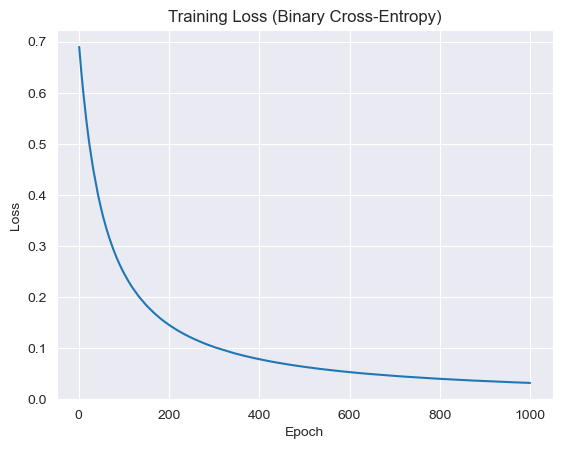

In [17]:
X = inputs_tensor.float()
y = targets_tensor.float()
X_mean = X.mean(0, keepdim=True)
X_std = X.std(0, keepdim=True)
X_std[X_std == 0] = 1.0

loss_history = []
for epoch in range(1000):
    total, n = 0.0, 0
    for xb, yb in train_dl:
        xb = (xb.float() - X_mean) / X_std
        yb = yb.float()
        opt.zero_grad()
        preds = model(xb)
        loss = bce_eps(preds, yb)
        loss.backward()
        opt.step()
        total += loss.item() * xb.size(0)
        n += xb.size(0)
    loss_history.append(total / n)
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss_history[-1]:.4f}")

with torch.no_grad():
    Xn = (X - X_mean) / X_std
    final_probs = model(Xn)
    final_cls = torch.round(final_probs)

print("\nFinal probabilities:\n", final_probs)
print("\nFinal classes:\n", final_cls)
print("\nTargets:\n", y)

plt.figure()
plt.plot(range(1, len(loss_history)+1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss (Binary Cross-Entropy)")
plt.grid(True)
plt.show()

